# 02 · EDA — Fichas de búsqueda (`fichas_texto_embedding`)

**Proyecto Integrador MNA — Cotejo ante-mortem / post-mortem (Querétaro)**

Análisis exploratorio de la tabla `proyecto_mna.fichas_busqueda.fichas_texto_embedding`, enriquecida con
los campos estructurados de `fichas_persona_silver`. Cubre: faltantes, estadísticas resumidas, atípicos,
cardinalidad, sesgo, tendencias temporales, correlación/entropía, análisis bivariado, nota sobre
imágenes y desequilibrio de clases.

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.titlesize'] = 12

from pyspark.sql.functions import col, when, to_date

# ── Cargar tablas ──────────────────────────────────────────────
T_PERSONA = "proyecto_mna.fichas_busqueda.fichas_persona_silver"
T_TEXTO   = "proyecto_mna.fichas_busqueda.fichas_texto_embedding"

df_persona = spark.table(T_PERSONA)
df_texto   = spark.table(T_TEXTO)

# Join: persona (structured) + texto (canonical text for embeddings)
cols_texto = ["id_ficha", "texto_rasgos", "texto_tatuajes", "texto_senas",
              "texto_vestimenta", "texto_completo"]
df = df_persona.join(df_texto.select(*cols_texto), on="id_ficha", how="left")

# ── Derivaciones ───────────────────────────────────────────────
# rango_edad
df = df.withColumn("rango_edad",
    when(col("edad_desaparicion") < 18, "0-17")
    .when(col("edad_desaparicion") <= 25, "18-25")
    .when(col("edad_desaparicion") <= 35, "26-35")
    .when(col("edad_desaparicion") <= 50, "36-50")
    .otherwise("51+"))

# fecha_hechos -> date
df = df.withColumn("fecha_hechos_dt", to_date(col("fecha_hechos"), "yyyy-MM-dd"))

# Normalizar estado_hechos (variantes de escritura del mismo valor)
df = df.withColumn("estado_norm",
    when(col("estado_hechos") == "MEXICO", "ESTADO DE MEXICO")
    .when(col("estado_hechos") == "Estado de México", "ESTADO DE MEXICO")
    .when(col("estado_hechos") == "MICH", "MICHOACAN")
    .when(col("estado_hechos") == "Ciudad de México", "CIUDAD DE MEXICO")
    .otherwise(col("estado_hechos")))

# ── Collect to pandas (22 filas: seguro en memoria) ─────────────
pdf = df.toPandas()
pdf["fecha_hechos_dt"] = pd.to_datetime(pdf["fecha_hechos_dt"])
pdf["rango_edad"] = pd.Categorical(
    pdf["rango_edad"], categories=["0-17", "18-25", "26-35", "36-50", "51+"], ordered=True)

print(f"Filas: {len(pdf)}  |  Columnas: {len(pdf.columns)}")
print(f"Rangos de edad: {pdf['rango_edad'].value_counts().sort_index().to_dict()}")
print(f"Sexo: {pdf['sexo'].value_counts().to_dict()}")
display(pdf[["id_ficha", "sexo", "edad_desaparicion", "rango_edad",
             "estatura_cm", "peso_kg", "estado_norm", "municipio_hechos", "fecha_hechos"]])

Filas: 22  |  Columnas: 41
Rangos de edad: {'0-17': 4, '18-25': 5, '26-35': 4, '36-50': 6, '51+': 3}
Sexo: {'HOMBRE': 16, 'MUJER': 6}


id_ficha,sexo,edad_desaparicion,rango_edad,estatura_cm,peso_kg,estado_norm,municipio_hechos,fecha_hechos
ac88888f5f7aeb313f0261d2,HOMBRE,20,18-25,170.0,70.0,MICHOACAN,MORELIA,2026-07-07
86eb3a1d36f5ce98a7d43241,HOMBRE,47,36-50,167.0,null,HIDALGO,TULA DE ALLENDE,2026-10-07
64ad384ac56279903f959eb4,HOMBRE,20,18-25,170.0,60.0,HIDALGO,TULA DE ALLENDE,2023-11-07
35431d228da023d0406d91b3,MUJER,26,26-35,null,95.0,TAMUALIPAS,VICTORIA,2020-10-07
51c511c748b10a227b645e1f,HOMBRE,17,0-17,165.0,60.0,BAJA CALIFORNIA SUR,LOS CABOS,2023-07-03
7dc24fc0cecd8e93581f28d1,HOMBRE,21,18-25,180.0,70.0,PUEBLA,ATLIXCO,2026-06-06
81a4d239d4d418e12bc2f8ed,MUJER,36,36-50,null,null,CHIAPAS,MORAZA,2026-07-07
35518a40de4801970b661390,HOMBRE,39,36-50,170.0,75.0,SINALOA,NAVOLATO,2023-11-07
ba19ac3806a286ea06560e5f,MUJER,34,26-35,null,66.0,MORELOS,AYALA,2023-01-05
2557853651e226cce2e73eba,HOMBRE,40,36-50,172.0,80.0,MICHOACAN,HUALCOACÁN,2020-07-06


## 1. Faltantes

% de NULL / vacío / `SIN_DATO` por columna. ¿Hay patrones de ausencia? Se cruza con `estado_hechos` y `rango_edad`.

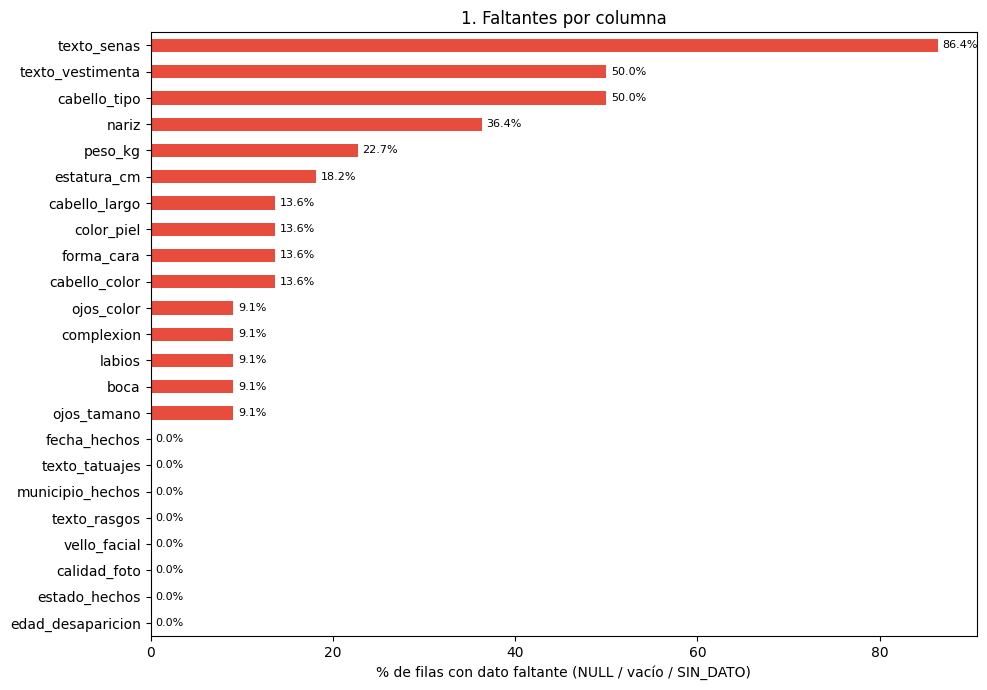


── Faltantes por estado (estado_norm) ──


estado_norm,n,estatura_falt,peso_falt,color_piel_sin_dato
BAJA CALIFORNIA SUR,1,0,0,0
CHIAPAS,1,1,1,0
CHIHUAHUA,1,1,1,0
CIUDAD DE MEXICO,1,0,1,1
ESTADO DE MEXICO,6,0,1,1
HIDALGO,2,0,1,0
MICHOACAN,3,0,0,0
MORELOS,1,1,0,0
PUEBLA,2,0,0,0
SINALOA,2,0,0,0



── Faltantes por rango_edad ──


rango_edad,n,estatura_falt_pct,peso_falt_pct,sin_dato_pct
0-17,4,0.0,50.0,50.0
18-25,5,0.0,0.0,0.0
26-35,4,50.0,0.0,25.0
36-50,6,16.666666666666664,33.33333333333333,0.0
51+,3,33.33333333333333,33.33333333333333,0.0


In [0]:
# Definir qué es "faltante" por tipo de columna
cols_num = ["edad_desaparicion", "estatura_cm", "peso_kg"]
cols_cat = ["complexion", "color_piel", "forma_cara", "cabello_color", "cabello_largo",
            "cabello_tipo", "ojos_color", "ojos_tamano", "nariz", "boca", "labios",
            "vello_facial", "calidad_foto"]
cols_str = ["estado_hechos", "municipio_hechos", "fecha_hechos",
            "texto_rasgos", "texto_tatuajes", "texto_senas", "texto_vestimenta"]

faltantes = {}
for c in cols_num:
    faltantes[c] = pdf[c].isna().sum() / len(pdf) * 100
for c in cols_cat:
    faltantes[c] = ((pdf[c].isna()) | (pdf[c] == "SIN_DATO") | (pdf[c] == "SIN_FOTO")).sum() / len(pdf) * 100
for c in cols_str:
    faltantes[c] = ((pdf[c].isna()) | (pdf[c] == "") | (pdf[c] == "SIN_DATO")).sum() / len(pdf) * 100

falt_df = pd.Series(faltantes).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
falt_df.plot.barh(ax=ax, color="#e74c3c")
ax.set_xlabel("% de filas con dato faltante (NULL / vacío / SIN_DATO)")
ax.set_title("1. Faltantes por columna")
for i, v in enumerate(falt_df):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

# Cruzar faltantes con estado_norm
print("\n── Faltantes por estado (estado_norm) ──")
falt_estado = pdf.groupby("estado_norm").agg(
    n=("id_ficha", "count"),
    estatura_falt=("estatura_cm", lambda x: x.isna().sum()),
    peso_falt=("peso_kg", lambda x: x.isna().sum()),
    color_piel_sin_dato=("color_piel", lambda x: (x == "SIN_DATO").sum()),
).reset_index()
display(falt_estado)

# Cruzar faltantes con rango_edad
print("\n── Faltantes por rango_edad ──")
falt_rango = pdf.groupby("rango_edad", observed=True).agg(
    n=("id_ficha", "count"),
    estatura_falt_pct=("estatura_cm", lambda x: x.isna().mean() * 100),
    peso_falt_pct=("peso_kg", lambda x: x.isna().mean() * 100),
    sin_dato_pct=("color_piel", lambda x: (x == "SIN_DATO").mean() * 100),
).reset_index()
display(falt_rango)

## 2. Estadísticas resumidas

Numéricas: min, p25, mediana, media, p75, max, desviación estándar.
Categóricas: valor modal y su %.

In [0]:
# Numéricas: min, p25, mediana, media, p75, max, std
numericas = ["edad_desaparicion", "estatura_cm", "peso_kg"]
stats = pdf[numericas].describe(percentiles=[.25, .5, .75]).T
stats = stats[["count", "min", "25%", "50%", "mean", "75%", "max", "std"]]
stats.columns = ["n", "min", "p25", "mediana", "media", "p75", "max", "std"]
print("── Estadísticas numéricas ──")
display(stats)

# Categóricas: valor modal y su %
categoricas = ["sexo", "complexion", "color_piel", "forma_cara", "cabello_color",
               "cabello_largo", "cabello_tipo", "ojos_color", "ojos_tamano",
               "nariz", "boca", "labios", "vello_facial", "calidad_foto",
               "estado_norm", "municipio_hechos"]
modales = []
for c in categoricas:
    vc = pdf[c].value_counts()
    if len(vc) > 0:
        moda = vc.index[0]
        pct = vc.iloc[0] / len(pdf) * 100
        n_distintos = len(vc)
    else:
        moda, pct, n_distintos = None, 0, 0
    modales.append({"columna": c, "valor_modal": moda, "n_distintos": n_distintos, "pct_modal": round(pct, 1)})
print("\n── Categóricas: valor modal ──")
display(pd.DataFrame(modales))

── Estadísticas numéricas ──


n,min,p25,mediana,media,p75,max,std
22.0,15.0,20.0,34.5,32.59090909090909,41.5,66.0,14.305041039235055
18.0,149.0,160.0,168.5,166.22222222222223,171.5,180.0,8.928181130591696
17.0,45.0,60.0,70.0,67.6470588235294,73.0,95.0,11.445201923025367



── Categóricas: valor modal ──


columna,valor_modal,n_distintos,pct_modal
sexo,HOMBRE,2,72.7
complexion,DELGADA,4,54.5
color_piel,MORENO,4,72.7
forma_cara,OVALADA,4,63.6
cabello_color,NEGRO,4,63.6
cabello_largo,MEDIANO,4,59.1
cabello_tipo,SIN_DATO,4,50.0
ojos_color,CAFES_OSCUROS,4,72.7
ojos_tamano,MEDIANOS,4,54.5
nariz,RECTA,3,59.1


## 3. Atípicos

IQR por `rango_edad` para estatura y peso. Rangos válidos: estatura 40–220 cm, peso 2–250 kg.
Boxplots. **No se eliminan atípicos**: solo se marcan. Se revisan incoherencias (estado vacío con municipio presente).

── Atípicos por rango válido ──
Estatura fuera de [40, 220] cm: 0
Peso fuera de [2, 250] kg: 0


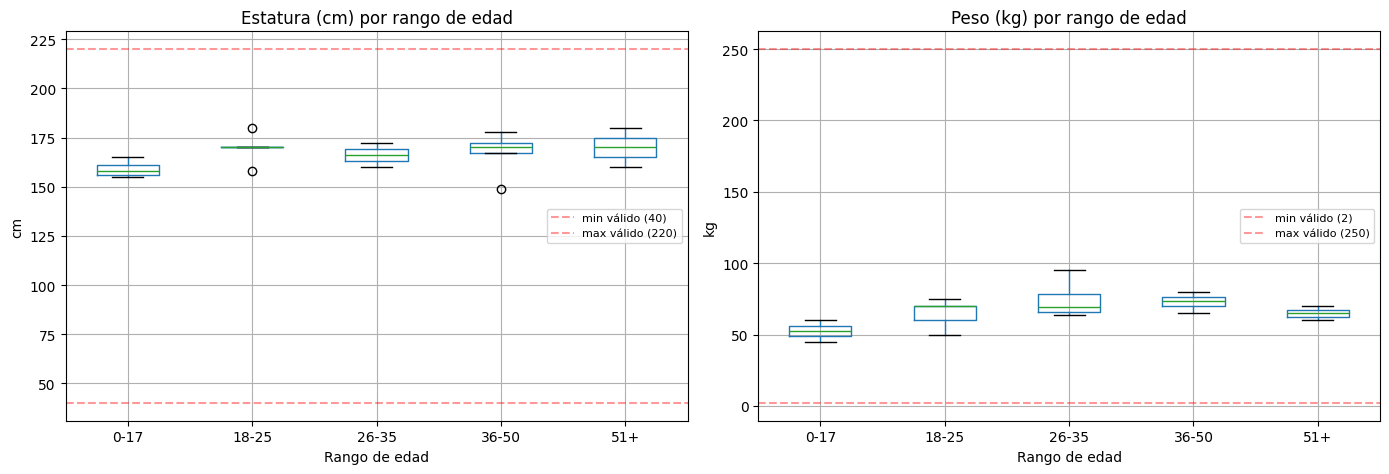


── IQR: Estatura (cm) por rango_edad ──
  0-17: n=4, Q1=155.8, Q3=161.2, IQR=5.5, lim=[147.5, 169.5], atip=0
  18-25: n=5, Q1=170.0, Q3=170.0, IQR=0.0, lim=[170.0, 170.0], atip=2
  26-35: n=2, Q1=163.0, Q3=169.0, IQR=6.0, lim=[154.0, 178.0], atip=0
  36-50: n=5, Q1=167.0, Q3=172.0, IQR=5.0, lim=[159.5, 179.5], atip=1
  51+: n=2, Q1=165.0, Q3=175.0, IQR=10.0, lim=[150.0, 190.0], atip=0

── IQR: Peso (kg) por rango_edad ──
  0-17: n=2, Q1=48.8, Q3=56.2, IQR=7.5, lim=[37.5, 67.5], atip=0
  18-25: n=5, Q1=60.0, Q3=70.0, IQR=10.0, lim=[45.0, 85.0], atip=0
  26-35: n=4, Q1=65.5, Q3=78.5, IQR=13.0, lim=[46.0, 98.0], atip=0
  36-50: n=4, Q1=70.2, Q3=76.2, IQR=6.0, lim=[61.2, 85.2], atip=0
  51+: n=2, Q1=62.5, Q3=67.5, IQR=5.0, lim=[55.0, 75.0], atip=0

── Incoherencias ──
Estado vacío con municipio presente: 0 casos
Fechas de hechos futuras (> hoy): 1


id_ficha,fecha_hechos,estado_hechos
86eb3a1d36f5ce98a7d43241,2026-10-07,HIDALGO


In [0]:
EST_MIN, EST_MAX = 40, 220
PESO_MIN, PESO_MAX = 2, 250

# Marcar atípicos por rango válido (no eliminar)
pdf["estatura_atipica"] = pdf["estatura_cm"].notna() & ((pdf["estatura_cm"] < EST_MIN) | (pdf["estatura_cm"] > EST_MAX))
pdf["peso_atipico"] = pdf["peso_kg"].notna() & ((pdf["peso_kg"] < PESO_MIN) | (pdf["peso_kg"] > PESO_MAX))

print("── Atípicos por rango válido ──")
print(f"Estatura fuera de [{EST_MIN}, {EST_MAX}] cm: {pdf['estatura_atipica'].sum()}")
print(f"Peso fuera de [{PESO_MIN}, {PESO_MAX}] kg: {pdf['peso_atipico'].sum()}")

# Boxplots por rango_edad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pdf_est = pdf[pdf["estatura_cm"].notna()]
pdf_est.boxplot(column="estatura_cm", by="rango_edad", ax=axes[0])
axes[0].set_title("Estatura (cm) por rango de edad")
axes[0].set_ylabel("cm"); axes[0].set_xlabel("Rango de edad")
axes[0].axhline(EST_MIN, color="red", ls="--", alpha=0.4, label=f"min válido ({EST_MIN})")
axes[0].axhline(EST_MAX, color="red", ls="--", alpha=0.4, label=f"max válido ({EST_MAX})")
axes[0].legend(fontsize=8)

pdf_peso = pdf[pdf["peso_kg"].notna()]
pdf_peso.boxplot(column="peso_kg", by="rango_edad", ax=axes[1])
axes[1].set_title("Peso (kg) por rango de edad")
axes[1].set_ylabel("kg"); axes[1].set_xlabel("Rango de edad")
axes[1].axhline(PESO_MIN, color="red", ls="--", alpha=0.4, label=f"min válido ({PESO_MIN})")
axes[1].axhline(PESO_MAX, color="red", ls="--", alpha=0.4, label=f"max válido ({PESO_MAX})")
axes[1].legend(fontsize=8)

plt.suptitle("")
plt.tight_layout()
plt.show()

# IQR detallado
for col_name, label in [("estatura_cm", "Estatura (cm)"), ("peso_kg", "Peso (kg)")]:
    print(f"\n── IQR: {label} por rango_edad ──")
    for rango in ["0-17", "18-25", "26-35", "36-50", "51+"]:
        subset = pdf[pdf["rango_edad"] == rango][col_name].dropna()
        if len(subset) == 0:
            continue
        q1, q3 = subset.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_out = ((subset < lower) | (subset > upper)).sum()
        print(f"  {rango}: n={len(subset)}, Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}, lim=[{lower:.1f}, {upper:.1f}], atip={n_out}")

# Incoherencias: estado vacío con municipio presente
print("\n── Incoherencias ──")
mask_estado_vacio = pdf["estado_hechos"].isna() | (pdf["estado_hechos"] == "") | (pdf["estado_hechos"] == "SIN_DATO")
mask_muni_presente = pdf["municipio_hechos"].notna() & (pdf["municipio_hechos"] != "") & (pdf["municipio_hechos"] != "SIN_DATO")
incoherentes = pdf[mask_estado_vacio & mask_muni_presente]
print(f"Estado vacío con municipio presente: {len(incoherentes)} casos")

# Fechas futuras
fecha_future = pdf[pdf["fecha_hechos_dt"] > pd.Timestamp.now()]
print(f"Fechas de hechos futuras (> hoy): {len(fecha_future)}")
if len(fecha_future) > 0:
    display(fecha_future[["id_ficha", "fecha_hechos", "estado_hechos"]])

## 4. Cardinalidad

Número de valores distintos por columna categórica (incluidos estado y municipio).
Se identifican variantes de escritura del mismo valor.

In [0]:
from difflib import get_close_matches

categoricas_card = ["sexo", "complexion", "color_piel", "forma_cara", "cabello_color",
                    "cabello_largo", "cabello_tipo", "ojos_color", "ojos_tamano",
                    "nariz", "boca", "labios", "vello_facial", "calidad_foto",
                    "estado_hechos", "estado_norm", "municipio_hechos"]

card_data = []
for c in categoricas_card:
    n_dist = pdf[c].nunique()
    card_data.append({"columna": c, "n_distintos": n_dist})
print("── Cardinalidad por columna categórica ──")
display(pd.DataFrame(card_data))

# Variantes de escritura: estado_hechos vs estado_norm
print("\n── Variantes de escritura en estado_hechos ──")
estados_raw = sorted(pdf["estado_hechos"].dropna().unique())
estados_norm = sorted(pdf["estado_norm"].dropna().unique())
print(f"estado_hechos (raw): {estados_raw}")
print(f"estado_norm (normalizado): {estados_norm}")

variantes = pdf.groupby("estado_norm")["estado_hechos"].unique().reset_index()
variantes["n_variantes"] = variantes["estado_hechos"].apply(len)
variantes_mul = variantes[variantes["n_variantes"] > 1]
if len(variantes_mul) > 0:
    print("\nEstados con variantes de escritura:")
    for _, r in variantes_mul.iterrows():
        print(f"  {r['estado_norm']}: {list(r['estado_hechos'])}")
else:
    print("\nNo se detectaron variantes (ya normalizado).")

# Municipios: buscar variantes (case-insensitive, typos)
muni_raw = sorted(pdf["municipio_hechos"].dropna().unique().tolist())
print(f"\n── Municipios ({len(muni_raw)} valores distintos) ──")
print(muni_raw)
# Detectar cercanos
for m in muni_raw:
    matches = get_close_matches(m, [x for x in muni_raw if x != m], cutoff=0.75)
    if matches:
        print(f"  Posible variante: '{m}' ~= {matches}")

── Cardinalidad por columna categórica ──


columna,n_distintos
sexo,2
complexion,4
color_piel,4
forma_cara,4
cabello_color,4
cabello_largo,4
cabello_tipo,4
ojos_color,4
ojos_tamano,4
nariz,3



── Variantes de escritura en estado_hechos ──
estado_hechos (raw): ['BAJA CALIFORNIA SUR', 'CHIAPAS', 'CHIHUAHUA', 'Ciudad de México', 'ESTADO DE MEXICO', 'Estado de México', 'HIDALGO', 'MEXICO', 'MICH', 'MICHOACAN', 'MORELOS', 'PUEBLA', 'SINALOA', 'TAMUALIPAS', 'VERACRUZ']
estado_norm (normalizado): ['BAJA CALIFORNIA SUR', 'CHIAPAS', 'CHIHUAHUA', 'CIUDAD DE MEXICO', 'ESTADO DE MEXICO', 'HIDALGO', 'MICHOACAN', 'MORELOS', 'PUEBLA', 'SINALOA', 'TAMUALIPAS', 'VERACRUZ']

Estados con variantes de escritura:
  ESTADO DE MEXICO: ['MEXICO', 'ESTADO DE MEXICO', 'Estado de México']
  MICHOACAN: ['MICHOACAN', 'MICH']

── Municipios (20 valores distintos) ──
['APATZINGAN', 'ATLIXCO', 'AYALA', 'CHIMALHUACAN', 'COATZACOALCOS', 'HUALCOACÁN', 'IZCALLI', 'LOS CABOS', 'MORAZA', 'MORELIA', 'NAVOLATO', 'NEZAHUALCOYOTL', 'NUEVO CASAS GRANDES', 'SAN MARTIN TEXMELUCAN', 'SAN MATEO ATENCO', 'TOLUCA', 'TULA DE ALLENDE', 'Toluuca', 'VICTORIA', 'Xochimilco']


## 5. Sesgo

Histogramas y skewness de edad, estatura y peso.
Se evalúa si hace falta una transformación (el modelo no es una regresión: se evalúa si basta usarlas como filtros con tolerancia).

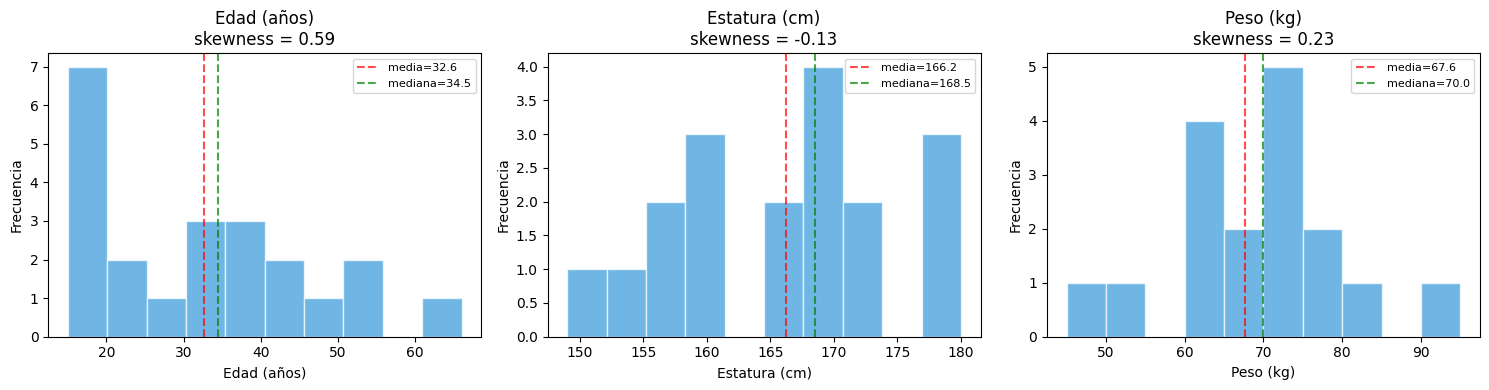

── Evaluación de transformación ──
  Edad: skewness=0.59 -> sesgo moderado
  Estatura: skewness=-0.13 -> aprox. simetrica
  Peso: skewness=0.23 -> aprox. simetrica

NOTA: El sistema es un pipeline de recuperacion (retrieval), no una regresion.
Las variables numericas se usaran como filtros con tolerancia (e.g. edad +/-5 anos,
estatura +/-10 cm). No se requiere transformacion log/box-cox de estos campos;
basta con documentar los rangos y definir las ventanas de tolerancia en el cotejo.
La skewness se reporta solo para fines de EDA.


In [0]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col_name, label in zip(axes,
    ["edad_desaparicion", "estatura_cm", "peso_kg"],
    ["Edad (años)", "Estatura (cm)", "Peso (kg)"]):
    data = pdf[col_name].dropna()
    ax.hist(data, bins=10, edgecolor="white", color="#3498db", alpha=0.7)
    s = data.skew()
    ax.set_title(f"{label}\nskewness = {s:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frecuencia")
    ax.axvline(data.mean(), color="red", ls="--", alpha=0.7, label=f"media={data.mean():.1f}")
    ax.axvline(data.median(), color="green", ls="--", alpha=0.7, label=f"mediana={data.median():.1f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("── Evaluación de transformación ──")
for col_name, label in [("edad_desaparicion", "Edad"), ("estatura_cm", "Estatura"), ("peso_kg", "Peso")]:
    s = pdf[col_name].skew()
    print(f"  {label}: skewness={s:.2f}", end="")
    if abs(s) < 0.5:
        print(" -> aprox. simetrica")
    elif abs(s) < 1:
        print(" -> sesgo moderado")
    else:
        print(" -> sesgo fuerte")

print("""
NOTA: El sistema es un pipeline de recuperacion (retrieval), no una regresion.
Las variables numericas se usaran como filtros con tolerancia (e.g. edad +/-5 anos,
estatura +/-10 cm). No se requiere transformacion log/box-cox de estos campos;
basta con documentar los rangos y definir las ventanas de tolerancia en el cotejo.
La skewness se reporta solo para fines de EDA.""")

## 6. Tendencias temporales

Fichas por ano y mes de `fecha_hechos` (grafica de linea). Anos transcurridos desde los hechos.

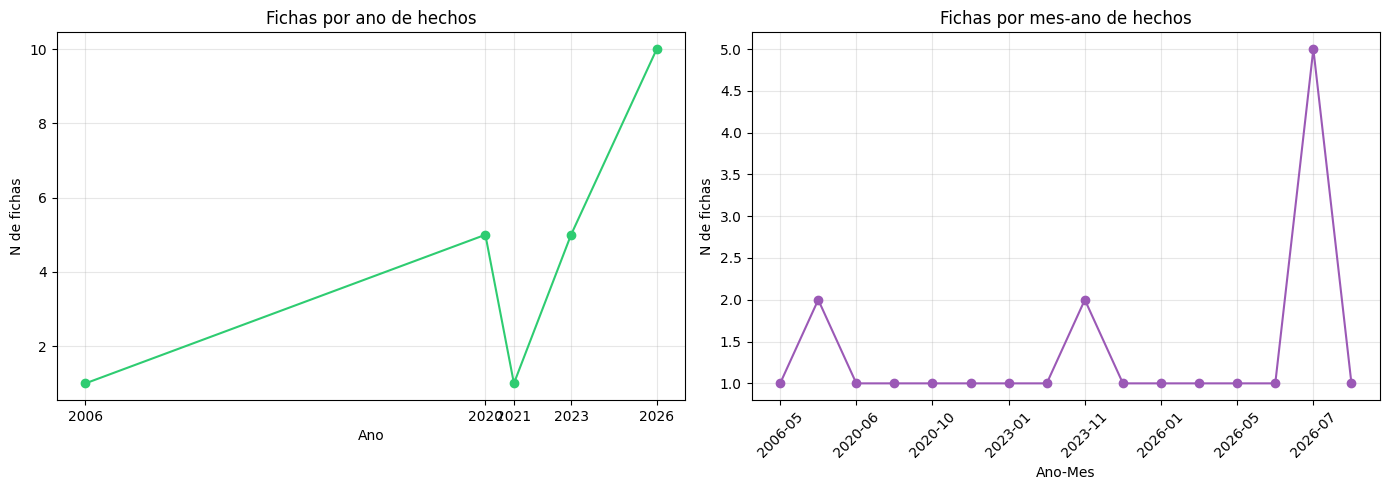


-- Anos transcurridos desde los hechos --


id_ficha,fecha_hechos,anos_transcurridos
771a163de8e6197519aeba98,2006-05-05,20.416153319644078
78b747b3cfc39c508dfed2a0,2020-05-22,6.368240930869268
3207a04c154be28494125539,2020-05-30,6.346338124572211
ab13879e1b48b862ec70703e,2020-06-26,6.272416153319644
2557853651e226cce2e73eba,2020-07-06,6.245037645448323
35431d228da023d0406d91b3,2020-10-07,5.990417522245037
c08df37b8bdd2afb61d5a938,2021-06-21,5.286789869952088
ba19ac3806a286ea06560e5f,2023-01-05,3.7453798767967146
51c511c748b10a227b645e1f,2023-07-03,3.2553045859000687
35518a40de4801970b661390,2023-11-07,2.9075975359342916



Resumen: min=-0.0, media=3.4, max=20.4 anos


In [0]:
pdf_t = pdf[pdf["fecha_hechos_dt"].notna()].copy()
pdf_t["ano"] = pdf_t["fecha_hechos_dt"].dt.year
pdf_t["ano_mes"] = pdf_t["fecha_hechos_dt"].dt.to_period("M").astype(str)

# Fichas por ano
por_ano = pdf_t.groupby("ano").size().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

por_ano.plot(kind="line", marker="o", ax=axes[0], color="#2ecc71")
axes[0].set_title("Fichas por ano de hechos")
axes[0].set_xlabel("Ano"); axes[0].set_ylabel("N de fichas")
axes[0].set_xticks(por_ano.index)
axes[0].grid(True, alpha=0.3)

# Por ano-mes
por_mes = pdf_t.groupby("ano_mes").size().sort_index()
por_mes.plot(kind="line", marker="o", ax=axes[1], color="#9b59b6")
axes[1].set_title("Fichas por mes-ano de hechos")
axes[1].set_xlabel("Ano-Mes"); axes[1].set_ylabel("N de fichas")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Anos transcurridos desde los hechos
pdf_t["anos_transcurridos"] = (pd.Timestamp.now() - pdf_t["fecha_hechos_dt"]).dt.days / 365.25
print("\n-- Anos transcurridos desde los hechos --")
display(pdf_t[["id_ficha", "fecha_hechos", "anos_transcurridos"]].sort_values("anos_transcurridos", ascending=False))
print(f"\nResumen: min={pdf_t['anos_transcurridos'].min():.1f}, "
      f"media={pdf_t['anos_transcurridos'].mean():.1f}, "
      f"max={pdf_t['anos_transcurridos'].max():.1f} anos")

## 7. Correlacion y entropia

No hay variable dependiente. Adecuacion: correlacion entre edad, estatura y peso (todas las fichas y solo menores de 18) y entropia de Shannon de cada columna categorica, para saber cuales distinguen mejor entre personas (ordenadas de mayor a menor).

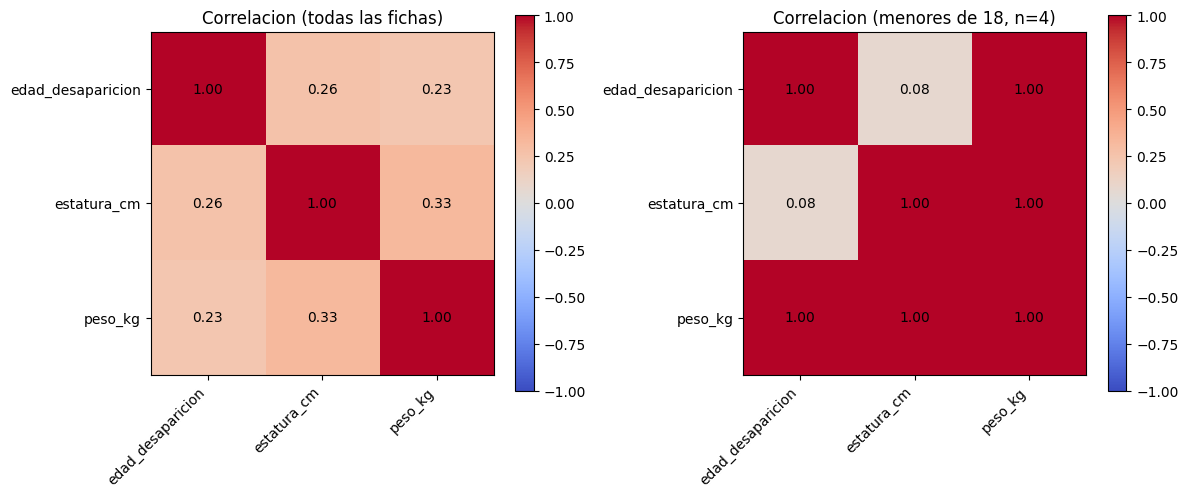


-- Correlacion (todas) --


edad_desaparicion,estatura_cm,peso_kg
1.0,0.2616095578750774,0.2313960948682544
0.2616095578750774,1.0,0.32633632285758857
0.2313960948682544,0.32633632285758857,1.0



-- Correlacion (menores de 18) --


edad_desaparicion,estatura_cm,peso_kg
1.0,0.07658395810674812,1.0
0.07658395810674812,1.0,1.0
1.0,1.0,1.0



-- Entropia de Shannon (excluyendo SIN_DATO) --


columna,entropia_shannon,n_valores_reales
municipio_hechos,4.278,20
estado_norm,3.266,12
labios,1.539,3
complexion,1.371,3
ojos_tamano,1.371,3
boca,1.371,3
cabello_tipo,1.349,3
cabello_largo,1.105,3
forma_cara,1.087,3
cabello_color,1.087,3



Mayor entropia = mas poder discriminatorio entre personas.


In [0]:
import math

cols_corr = ["edad_desaparicion", "estatura_cm", "peso_kg"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Todas
corr_all = pdf[cols_corr].corr()
im0 = axes[0].imshow(corr_all, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("Correlacion (todas las fichas)")
axes[0].set_xticks(range(len(cols_corr))); axes[0].set_yticks(range(len(cols_corr)))
axes[0].set_xticklabels(cols_corr, rotation=45, ha="right")
axes[0].set_yticklabels(cols_corr)
for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        axes[0].text(j, i, f"{corr_all.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im0, ax=axes[0])

# Solo menores de 18
pdf_menores = pdf[pdf["edad_desaparicion"] < 18]
if len(pdf_menores) >= 3:
    corr_men = pdf_menores[cols_corr].corr()
    im1 = axes[1].imshow(corr_men, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title(f"Correlacion (menores de 18, n={len(pdf_menores)})")
    axes[1].set_xticks(range(len(cols_corr))); axes[1].set_yticks(range(len(cols_corr)))
    axes[1].set_xticklabels(cols_corr, rotation=45, ha="right")
    axes[1].set_yticklabels(cols_corr)
    for i in range(len(cols_corr)):
        for j in range(len(cols_corr)):
            axes[1].text(j, i, f"{corr_men.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
    plt.colorbar(im1, ax=axes[1])
else:
    axes[1].text(0.5, 0.5, f"Insuficientes datos\n(n={len(pdf_menores)})", ha="center", va="center")
    axes[1].set_title("Menores de 18")

plt.tight_layout()
plt.show()

print("\n-- Correlacion (todas) --")
display(corr_all)
if len(pdf_menores) >= 3:
    print("\n-- Correlacion (menores de 18) --")
    display(corr_men)

# Entropia de Shannon de cada categorica
def shannon_entropy(series):
    vc = series.dropna().value_counts()
    p = vc / vc.sum()
    return -(p * np.log2(p)).sum()

categoricas_ent = ["sexo", "complexion", "color_piel", "forma_cara", "cabello_color",
                   "cabello_largo", "cabello_tipo", "ojos_color", "ojos_tamano",
                   "nariz", "boca", "labios", "vello_facial", "calidad_foto",
                   "estado_norm", "municipio_hechos"]

entropias = []
for c in categoricas_ent:
    # Excluir SIN_DATO para que la entropia mida discriminacion real
    s = pdf[c][pdf[c] != "SIN_DATO"]
    if len(s) > 0:
        ent = shannon_entropy(s)
    else:
        ent = 0.0
    entropias.append({"columna": c, "entropia_shannon": round(ent, 3), "n_valores_reales": s.nunique()})

ent_df = pd.DataFrame(entropias).sort_values("entropia_shannon", ascending=False)
print("\n-- Entropia de Shannon (excluyendo SIN_DATO) --")
display(ent_df)
print("\nMayor entropia = mas poder discriminatorio entre personas.")

## 8. Analisis bivariado

Sexo x rango_edad; % con tatuaje, sena y vestimenta por sexo y por rango_edad; completitud de rasgos por estado_hechos.

── Sexo x rango_edad ──


HOMBRE,MUJER
1,3
5,0
2,2
5,1
3,0



── % con rasgo por sexo ──


Tatuaje,Sena particular,Vestimenta
100.0,6.25,43.75
100.0,33.33333333333333,66.66666666666666



── % con rasgo por rango_edad ──


Tatuaje,Sena particular,Vestimenta
100.0,25.0,75.0
100.0,0.0,60.0
100.0,25.0,50.0
100.0,16.666666666666664,50.0
100.0,0.0,0.0



── Completitud de rasgos por estado ──


estado_norm,n,completitud_media,estatura_pct,peso_pct
CHIAPAS,1,100.0,0.0,0.0
CHIHUAHUA,1,100.0,0.0,0.0
MICHOACAN,3,97.22222222222221,100.0,100.0
SINALOA,2,95.83333333333333,100.0,100.0
BAJA CALIFORNIA SUR,1,91.66666666666666,100.0,100.0
MORELOS,1,91.66666666666666,0.0,100.0
PUEBLA,2,91.66666666666666,100.0,100.0
TAMUALIPAS,1,91.66666666666666,0.0,100.0
VERACRUZ,1,83.33333333333334,100.0,100.0
HIDALGO,2,79.16666666666666,100.0,50.0


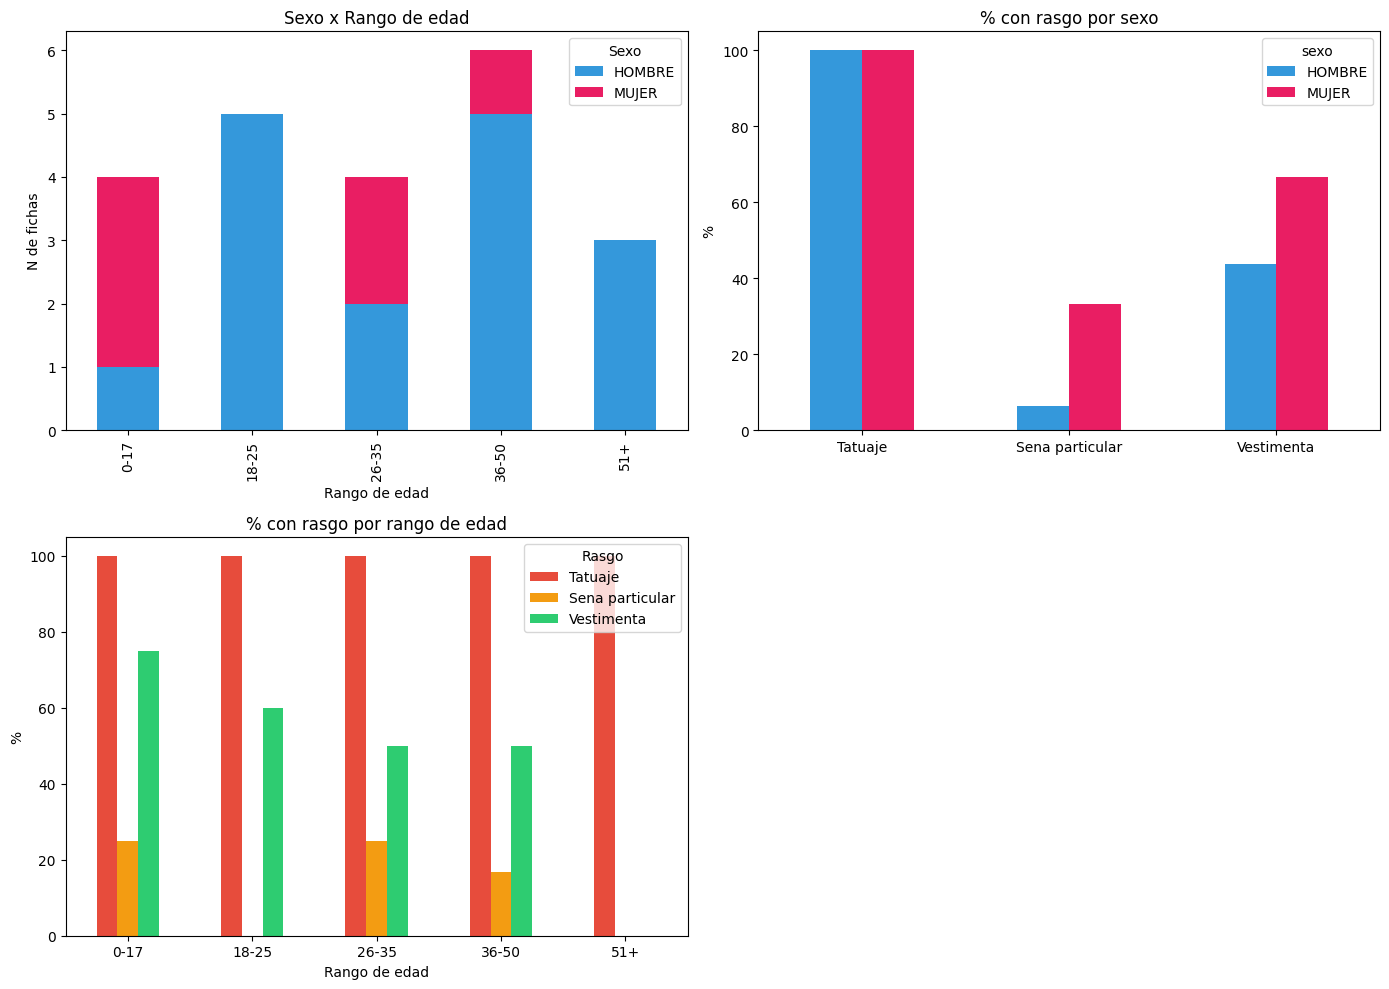

In [0]:
# Sexo x rango_edad
ct = pd.crosstab(pdf["rango_edad"], pdf["sexo"])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ct.plot(kind="bar", stacked=True, ax=axes[0, 0], color=["#3498db", "#e91e63"])
axes[0, 0].set_title("Sexo x Rango de edad")
axes[0, 0].set_xlabel("Rango de edad"); axes[0, 0].set_ylabel("N de fichas")
axes[0, 0].legend(title="Sexo")
print("── Sexo x rango_edad ──")
display(ct)

# % con tatuaje, sena y vestimenta
pdf["tiene_tatuaje"] = pdf["n_tatuajes"] > 0
pdf["tiene_sena"] = pdf["n_senas"] > 0
pdf["tiene_vestimenta"] = pdf["n_prendas"] > 0

rasgos = ["tiene_tatuaje", "tiene_sena", "tiene_vestimenta"]
labels_r = ["Tatuaje", "Sena particular", "Vestimenta"]

# Por sexo
pct_sexo = pdf.groupby("sexo")[rasgos].mean() * 100
pct_sexo.columns = labels_r
print("\n── % con rasgo por sexo ──")
display(pct_sexo)
pct_sexo.T.plot(kind="bar", ax=axes[0, 1], color=["#3498db", "#e91e63"])
axes[0, 1].set_title("% con rasgo por sexo"); axes[0, 1].set_ylabel("%")
axes[0, 1].set_xticklabels(labels_r, rotation=0)

# Por rango_edad
pct_rango = pdf.groupby("rango_edad", observed=True)[rasgos].mean() * 100
pct_rango.columns = labels_r
print("\n── % con rasgo por rango_edad ──")
display(pct_rango)
pct_rango.plot(kind="bar", ax=axes[1, 0], color=["#e74c3c", "#f39c12", "#2ecc71"])
axes[1, 0].set_title("% con rasgo por rango de edad")
axes[1, 0].set_xlabel("Rango de edad"); axes[1, 0].set_ylabel("%")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title="Rasgo")

# Completitud de rasgos por estado_hechos
rasgos_cols = ["complexion", "color_piel", "forma_cara", "cabello_color", "cabello_largo",
               "cabello_tipo", "ojos_color", "ojos_tamano", "nariz", "boca", "labios", "vello_facial"]
pdf["completitud_rasgos"] = pdf[rasgos_cols].apply(lambda row: (row != "SIN_DATO").sum(), axis=1)
pdf["completitud_pct"] = pdf["completitud_rasgos"] / len(rasgos_cols) * 100

comp_estado = pdf.groupby("estado_norm").agg(
    n=("id_ficha", "count"),
    completitud_media=("completitud_pct", "mean"),
    estatura_pct=("estatura_cm", lambda x: x.notna().mean() * 100),
    peso_pct=("peso_kg", lambda x: x.notna().mean() * 100),
).reset_index().sort_values("completitud_media", ascending=False)
print("\n── Completitud de rasgos por estado ──")
display(comp_estado)

axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

## 9. Imagenes

**No aplica en la Fase 1 (solo texto).** La fotografia en vida de cada ficha se uso unicamente como **insumo del LLM multimodal** durante la extraccion (notebook `01_extraccion_fichas_llm`): el modelo proceso texto + imagen para producir los campos estructurados y el texto canonico que alimentan los embeddings. En esta fase de EDA trabajamos exclusivamente con los datos estructurados extraidos, no con las imagenes originales.

## 10. Desequilibrio de clases

No hay variable objetivo. Adecuacion: proporcion hombres/mujeres y por rango_edad. Se menciona que en recuperacion hay a lo sumo un candidato correcto entre muchos, por lo que se evalua con recall@k.

Proporcion H/M: {'HOMBRE': 16, 'MUJER': 6}
Ratio H/M: 2.67

── Sexo por rango_edad ──


HOMBRE,MUJER
1,3
5,0
2,2
5,1
3,0


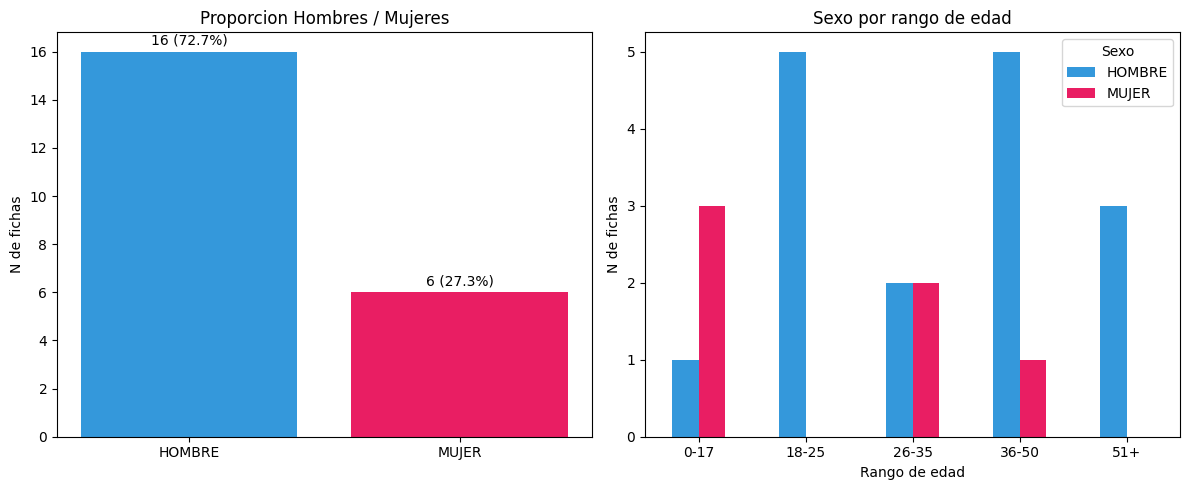


── Nota sobre desequilibrio en recuperacion ──
En este problema no existe una variable objetivo clasica. El "desequilibrio"
se manifiesta en el espacio de recuperacion: para cada consulta (ficha post-mortem),
hay a lo sumo UN candidato correcto entre potencialmente muchos. Por ello el
rendimiento se evalua con recall@k (aparece el correcto en los top-k?) y no
con accuracy/F1. La proporcion H/M y la distribucion por edad documentan el
sesgo demografico del corpus, no un desequilibrio de clases a corregir.


In [0]:
# Proporcion H/M y por rango_edad
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sexo_counts = pdf["sexo"].value_counts()
axes[0].bar(sexo_counts.index, sexo_counts.values, color=["#3498db", "#e91e63"])
axes[0].set_title("Proporcion Hombres / Mujeres")
axes[0].set_ylabel("N de fichas")
for i, v in enumerate(sexo_counts.values):
    axes[0].text(i, v + 0.3, f"{v} ({v/len(pdf)*100:.1f}%)", ha="center")
print(f"Proporcion H/M: {sexo_counts.to_dict()}")
print(f"Ratio H/M: {sexo_counts.get('HOMBRE', 0) / max(sexo_counts.get('MUJER', 1), 1):.2f}")

ct_sexo_rango = pd.crosstab(pdf["rango_edad"], pdf["sexo"])
ct_sexo_rango.plot(kind="bar", stacked=False, ax=axes[1], color=["#3498db", "#e91e63"])
axes[1].set_title("Sexo por rango de edad")
axes[1].set_xlabel("Rango de edad"); axes[1].set_ylabel("N de fichas")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Sexo")
print("\n── Sexo por rango_edad ──")
display(ct_sexo_rango)

plt.tight_layout()
plt.show()

print("""
── Nota sobre desequilibrio en recuperacion ──
En este problema no existe una variable objetivo clasica. El "desequilibrio"
se manifiesta en el espacio de recuperacion: para cada consulta (ficha post-mortem),
hay a lo sumo UN candidato correcto entre potencialmente muchos. Por ello el
rendimiento se evalua con recall@k (aparece el correcto en los top-k?) y no
con accuracy/F1. La proporcion H/M y la distribucion por edad documentan el
sesgo demografico del corpus, no un desequilibrio de clases a corregir.""")